# data-conduit: Workflow v2 style demo
This notebook mirrors the structure of the old `Workflow_v2` demo, but is fully aligned with the new `src/data_conduit` architecture.

## What this demo covers
1. Rig layout + virtual-map setup
2. Multi-device orchestration with `MultiDevice`/`Nosepoke`
3. Single-device wrappers (`SoundCard`, `Camera0Frames`)
4. Non-binary file loaders (`ExperimentEvents`, `VideoData`, `VisualEnvironment`)
5. TTL sync utilities (`ttlsync`)
6. Global clock mapping (`globaltimes`)
7. Segmentation helpers (`segment`)
8. A unified `results` dictionary pattern

## How to use this notebook (tutorial mode)
This notebook is intended as a guided tutorial, not just a smoke test.

### Recommended run order
1. Imports and environment setup
2. Paths + rig layout
3. Build `virtual_maps`
4. Run `MultiDevice` and inspect outputs
5. Run wrappers (`Nosepoke`, `SoundCard`, `Camera0Frames`, filetypes)
6. Run synthetic TTL/global-time examples
7. Run the master workflow function
8. Run diagnostics + smoke tests

### What to look for at each stage
- Are objects created successfully?
- Are DataFrames/DataArrays non-empty and shaped as expected?
- Do virtual coordinates map to the expected hardware (`device`, `register`, `localID`)?
- Are time-sync metrics plausible (slope near 1, high $R^2$)?

In [1]:
# 1) Imports
import os
import importlib
import numpy as np
import pandas as pd

# During notebook development, reload ttlsync so newly added helpers are visible without kernel restart.
import data_conduit.ttlsync as _ttlsync_pkg
import data_conduit.ttlsync.ttlsync_core as _ttlsync_core
import data_conduit.ttlsync.ttl_visualisation as _ttlsync_viz
importlib.reload(_ttlsync_core)
importlib.reload(_ttlsync_viz)
importlib.reload(_ttlsync_pkg)

from data_conduit.multisource import MultiDevice, Nosepoke
from data_conduit.datasource.devices import SoundCard, Camera0Frames
from data_conduit.datasource.filetypes import ExperimentEvents, VideoData, VisualEnvironment
from data_conduit.ttlsync import (
    TTLSyncModel,
    align_pulse_tables,
    convert_timebase,
    extract_ttl_segments,
    fit_linear_timebase,
    get_ttl_timebase_conversion,
    get_npx_to_bonsai_time_conversion,
    plot_timebase_fit,
    plot_ttl_pulse_trains,
)
from data_conduit.globaltimes import create_global_clock, index_map_util
from data_conduit.segment import segment_boolean_series, slice_event_windows

from pathlib import Path

os.chdir("/home/callum/Keshavarzi-Lab-Workspace/data-conduit")
print(Path.cwd())
cwd = os.getcwd()
print(f"Current directory: {cwd}")

/home/callum/Keshavarzi-Lab-Workspace/data-conduit
Current directory: /home/callum/Keshavarzi-Lab-Workspace/data-conduit


## 2) User-configurable paths + rig layout
Set these values for your own experiment directory before running load cells.

### Conceptual model (core idea)
The library maps physical acquisition structure into queryable arrays.

- **Device**: board folder (e.g. `Behavior0`)
- **Register**: stream address (e.g. `32`)
- **LocalID**: channel column within a register (e.g. `DIPort0`)
- **Peripheral**: your global user-facing label (e.g. `Nosepoke0`)
- **Data key**: grouped modality label (e.g. `Activations`)

`virtual_maps` creates a stable mapping from peripheral names to `(device, register, localID)` so downstream analysis can stay hardware-agnostic.

In [2]:
# 2) Paths + rig layout (edit for your environment)
# Updated to use the newer Misc dataset provided by user
experiment_directory_path = "./Misc/2025-10-14T18-24-42"
harp_device_yaml_path = "./device.yml"
soundcard_yaml_path = "./soundcard.yml"
npx_sync_path = "./Misc/sync_channel_1014.npy"

# Dedicated behavior board used for TTL sync pulse output in this session
sync_behavior_device = "Behavior3"

# Example: two behavior boards, 3 nosepokes each
device_list = ["Behavior0", "Behavior1"]
device_IDs = {"Behavior0": "ID_0", "Behavior1": "ID_1"}
device_registers_dict = {
    "Behavior0": ["8", "32", "34", "35", "44", "49", "50", "51", "78", "92"],
    "Behavior1": ["8", "32", "34", "35", "44", "49", "50", "51", "78", "92"],
}

peripheral_list = ["Nosepoke0", "Nosepoke1", "Nosepoke2", "Nosepoke3", "Nosepoke4", "Nosepoke5"]
peripheral_localIDs = {
    "Activations": ["DIPort0", "DIPort1", "DIPort2"],
    "LED_Activations": ["DOPort0", "DOPort1", "DOPort2"],
}
data_registerIDs = {
    "Activations": {"DIPort0": "32", "DIPort1": "32", "DIPort2": "32"},
    "LED_Activations": {"DOPort0": "34", "DOPort1": "34", "DOPort2": "34"},
}

print("experiment_directory_path:", experiment_directory_path)
print("npx_sync_path:", npx_sync_path)

experiment_directory_path: ./Misc/2025-10-14T18-24-42
npx_sync_path: ./Misc/sync_channel_1014.npy


## 3) Build `virtual_maps` (global peripheral → device/register/localID)

In [3]:
# 3) Build virtual_maps using the new MultiDevice helper
virtual_maps = MultiDevice.build_virtual_maps(
    channel_list=peripheral_list,
    data_registerIDs=data_registerIDs,
    device_list=device_list,
    channel_localIDs=peripheral_localIDs,
 )

print("data_keys:", list(virtual_maps.keys()))
print("sample mapping:")
for k, v in list(virtual_maps["Activations"].items())[:3]:
    print(f"  {k} -> {v}")

data_keys: ['Activations', 'LED_Activations']
sample mapping:
  Nosepoke0 -> {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke1 -> {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke2 -> {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort2'}


## 4) Instantiate `MultiDevice` (full pipeline)
This runs the new pipeline: load dfs_dict → collect timestamps → build data arrays and lookup arrays.

In [4]:
# 4-precheck) Confirm new dataset assets exist
from pathlib import Path

print("cwd:", Path.cwd())
print("experiment dir exists:", Path(experiment_directory_path).is_dir())
print("device yml exists:", Path(harp_device_yaml_path).is_file())
print("soundcard yml exists:", Path(soundcard_yaml_path).is_file())
print("npx sync exists:", Path(npx_sync_path).is_file())

cwd: /home/callum/Keshavarzi-Lab-Workspace/data-conduit
experiment dir exists: True
device yml exists: True
soundcard yml exists: True
npx sync exists: True


In [5]:
# 4) MultiDevice demo (uncomment when paths are valid)
multidevice = MultiDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type="Behavior",
    device_list=device_list,
    device_IDs=device_IDs,
    device_registers_dict=device_registers_dict,
    virtual_maps=virtual_maps,
    data_keys=list(virtual_maps.keys()),
    global_coord_name="peripherals",
    virtual_coord_names=["device", "register", "localID"],
    verbose=False,
)

print("data_arrays:", list(multidevice.data_arrays.keys()))
print("lookup_arrays:", list(multidevice.lookup_arrays.keys()))

data_arrays: ['Activations', 'LED_Activations']
lookup_arrays: ['Activations', 'LED_Activations']


In [6]:
# 4a) Inspect MultiDevice outputs in a tutorial-friendly way
print("data_arrays keys:", list(multidevice.data_arrays.keys()))
print("lookup_arrays keys:", list(multidevice.lookup_arrays.keys()))

for key in multidevice.data_arrays:
    da = multidevice.data_arrays[key]
    print(f"\n=== {key} ===")
    print("shape:", da.shape)
    print("dims:", da.dims)
    print("coords:", list(da.coords))
    try:
        df = da.to_dataframe().reset_index()
        display(df.head(8))
    except Exception as e:
        print(f"Could not convert {key} to DataFrame: {type(e).__name__}: {e}")

for key in multidevice.lookup_arrays:
    lk = multidevice.lookup_arrays[key]
    print(f"\n=== lookup:{key} ===")
    try:
        display(lk.to_dataframe().reset_index().head(12))
    except Exception as e:
        print(f"Could not display lookup {key}: {type(e).__name__}: {e}")

data_arrays keys: ['Activations', 'LED_Activations']
lookup_arrays keys: ['Activations', 'LED_Activations']

=== Activations ===
shape: (1081865, 6)
dims: ('Time', 'peripherals')
coords: ['Time', 'peripherals', 'device', 'register', 'localID']


,Time,peripherals,device,register,localID,Activations_data
0,29872.272992,Nosepoke0,Behavior0,32,DIPort0,NaN
1,29872.272992,Nosepoke1,Behavior0,32,DIPort1,NaN
2,29872.272992,Nosepoke2,Behavior0,32,DIPort2,NaN
3,29872.272992,Nosepoke3,Behavior1,32,DIPort0,NaN
4,29872.272992,Nosepoke4,Behavior1,32,DIPort1,NaN
5,29872.272992,Nosepoke5,Behavior1,32,DIPort2,NaN
6,29872.273984,Nosepoke0,Behavior0,32,DIPort0,NaN
7,29872.273984,Nosepoke1,Behavior0,32,DIPort1,NaN



=== LED_Activations ===
shape: (1081865, 6)
dims: ('Time', 'peripherals')
coords: ['Time', 'peripherals', 'device', 'register', 'localID']


,Time,peripherals,device,register,localID,LED_Activations_data
0,29872.272992,Nosepoke0,Behavior0,34,DOPort0,NaN
1,29872.272992,Nosepoke1,Behavior0,34,DOPort1,NaN
2,29872.272992,Nosepoke2,Behavior0,34,DOPort2,NaN
3,29872.272992,Nosepoke3,Behavior1,34,DOPort0,NaN
4,29872.272992,Nosepoke4,Behavior1,34,DOPort1,NaN
5,29872.272992,Nosepoke5,Behavior1,34,DOPort2,NaN
6,29872.273984,Nosepoke0,Behavior0,34,DOPort0,NaN
7,29872.273984,Nosepoke1,Behavior0,34,DOPort1,NaN



=== lookup:Activations ===


,peripherals,device,register,localID,Activations_lookup
0,Nosepoke0,Behavior0,32,DIPort0,True
1,Nosepoke1,Behavior0,32,DIPort1,True
2,Nosepoke2,Behavior0,32,DIPort2,True
3,Nosepoke3,Behavior1,32,DIPort0,True
4,Nosepoke4,Behavior1,32,DIPort1,True
5,Nosepoke5,Behavior1,32,DIPort2,True



=== lookup:LED_Activations ===


,peripherals,device,register,localID,LED_Activations_lookup
0,Nosepoke0,Behavior0,34,DOPort0,True
1,Nosepoke1,Behavior0,34,DOPort1,True
2,Nosepoke2,Behavior0,34,DOPort2,True
3,Nosepoke3,Behavior1,34,DOPort0,True
4,Nosepoke4,Behavior1,34,DOPort1,True
5,Nosepoke5,Behavior1,34,DOPort2,True


In [7]:
# 4b) Optional Nosepoke convenience wrapper (same architecture)
nosepoke = Nosepoke(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_list=device_list,
    channel_list=peripheral_list,
    data_registerIDs=data_registerIDs,
    data_keys=list(data_registerIDs.keys()),
    verbose=False,
)

for dk, da in nosepoke.data_arrays.items():
    print(dk, da.shape)

Activations (339, 6)
LED_Activations (339, 6)


## 5) Single-device + filetype loaders
These mirror the old workflow sections but use new classes from `src/data_conduit/datasource`.

In [8]:
# 5) Single-device wrappers (uncomment when paths are valid)
soundcard = SoundCard(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=soundcard_yaml_path,
    verbose=False,
)
print("SoundCard arrays:", list(soundcard.data_arrays.keys()))

camera0 = Camera0Frames(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    verbose=False,
)
print("Camera0 arrays:", list(camera0.data_arrays.keys()))

##== filetypes
events = ExperimentEvents(experiment_directory_path=experiment_directory_path, verbose=False)
video_data = VideoData(experiment_directory_path=experiment_directory_path, verbose=False)
vis_env = VisualEnvironment(experiment_directory_path=experiment_directory_path, verbose=False)

display(events.dfs_dict)

SoundCard arrays: ['PlaySoundFreq', 'StopLog', 'AttenuationRight']
Camera0 arrays: ['Behavior0_Camera0Frame', 'Behavior1_Camera0Frame', 'Behavior2_Camera0Frame', 'Behavior3_Camera0Frame', 'Behavior4_Camera0Frame', 'Behavior5_Camera0Frame']


{'ExperimentEvents': {'ExperimentEvents_1904-01-01T08-00-00':                                                           Event
  Time                                                           
  29872.322976                                   Workflow started
  29874.790976                               Request camera start
  29875.153984                                   Start Sync Pulse
  29875.629984                                  Start trial logic
  29875.894976                                        Trial start
  29875.894976                                  Rotating nosepoke
  29875.924992                           Start mismatch rotations
  29878.962976                         Performing outer rotations
  29888.980992  Target zone available (X Y : 395 290 - Radius ...
  30113.034976                              Target zone triggered
  30113.040992                                         Await poke
  30113.082112  Poke: {Success=False, ChosenPort=-1, CorrectPo...
  30113.096000  

In [9]:
# 5a) Inspect filetype outputs (head + schema)
print("ExperimentEvents tables:", list(events.dfs_dict.keys()) if isinstance(events.dfs_dict, dict) else type(events.dfs_dict))
print("VideoData tables:", list(video_data.dfs_dict.keys()) if isinstance(video_data.dfs_dict, dict) else type(video_data.dfs_dict))
print("VisualEnvironment tables:", list(vis_env.dfs_dict.keys()) if isinstance(vis_env.dfs_dict, dict) else type(vis_env.dfs_dict))

def _display_first_table(dfs_obj, title):
    print(f"\n--- {title} ---")
    if isinstance(dfs_obj, dict) and len(dfs_obj) > 0:
        first_key = next(iter(dfs_obj))
        first_val = dfs_obj[first_key]
        if hasattr(first_val, "head"):
            print("first key:", first_key)
            display(first_val.head(8))
        elif isinstance(first_val, dict):
            k2 = next(iter(first_val))
            print("first keys:", first_key, "->", k2)
            display(first_val[k2].head(8))
        else:
            print(type(first_val))
    else:
        print(type(dfs_obj))

_display_first_table(events.dfs_dict, "ExperimentEvents")
_display_first_table(video_data.dfs_dict, "VideoData")
_display_first_table(vis_env.dfs_dict, "VisualEnvironment")

ExperimentEvents tables: ['ExperimentEvents']
VideoData tables: ['VideoData']
VisualEnvironment tables: ['VisualEnvironment']

--- ExperimentEvents ---
first keys: ExperimentEvents -> ExperimentEvents_1904-01-01T08-00-00


,Event
Time,
29872.322976,Workflow started
29874.790976,Request camera start
29875.153984,Start Sync Pulse
29875.629984,Start trial logic
29875.894976,Trial start
29875.894976,Rotating nosepoke
29875.924992,Start mismatch rotations
29878.962976,Performing outer rotations



--- VideoData ---
first keys: VideoData -> VideoData_1904-01-01T08-00-00


,FrameID,Timestamp
Time,,
29874.792576,489850,29849558403592
29874.809216,489851,29849575068920
29874.825856,489852,29849591735704
29874.842528,489853,29849608401160
29874.859200,489854,29849625063616
29874.875872,489855,29849641730056
29874.892544,489856,29849658396080
29874.909216,489857,29849675062136



--- VisualEnvironment ---
first keys: VisualEnvironment -> VisualEnvironment_1904-01-01T08-00-00


,Value,Landmark,Landmark_Proximal,Gratings,Firefly
Time,,,,,
29875.880000,Visual environment OFF,None,None,None,None
29878.962976,Visual environment ON,Landmark spheric photo - botanical garden tree...,Prox Landmarktransparent image - paradise bird...,Gratings : OFF,Firefly : OFF
30113.132992,Visual environment OFF,None,None,None,None
30116.152000,Visual environment ON,Landmark spheric photo - botanical garden tree...,Prox Landmarktransparent image - paradise bird...,Gratings : OFF,Firefly : OFF


## 6) TTL sync + global times + segmentation (synthetic self-contained demo)

In [10]:
# 6) Synthetic TTL sync and global clock mapping
t_ref = np.linspace(0, 20, 20001)
v_ref = ((t_ref % 1.0) < 0.2).astype(float)

# Target clock has slight drift + offset
t_tgt = t_ref * 1.0018 + 0.025
v_tgt = v_ref.copy()

ref_segments, ref_offset = extract_ttl_segments(t_ref, v_ref, drop_inactive=True)
tgt_segments, tgt_offset = extract_ttl_segments(t_tgt, v_tgt, drop_inactive=True)

aligned_ref, aligned_tgt = align_pulse_tables(ref_segments, tgt_segments)
fit_stats = fit_linear_timebase(aligned_ref, aligned_tgt, use="start")
sync_model = TTLSyncModel(**fit_stats)

# Convert target times into reference clock
t_tgt_to_ref = sync_model.transform(t_tgt)

# Global clock + index map
global_clock = create_global_clock(0.0, 20.0, 0.001, include_end_time=True)
index_map = index_map_util(global_clock, t_tgt_to_ref, match_type="nearest")

# Segmentation and event windows
state_series = pd.Series(((t_ref % 2.5) < 0.6).astype(int), index=t_ref, name="state")
segments = segment_boolean_series(state_series, min_duration=0.05, drop_inactive=True)

df_signal = pd.DataFrame({"signal": np.sin(2 * np.pi * 0.75 * t_ref)}, index=t_ref)
event_times = [3.0, 7.5, 12.0, 16.5]
windows = slice_event_windows(df_signal, event_times, pre=0.5, post=0.75)

{
    "sync_r2": sync_model.r2,
    "sync_slope": sync_model.slope,
    "n_segments": len(segments),
    "global_clock_bins": len(global_clock),
    "mapped_shape": index_map["index_position_array"].shape,
    "window_sizes": {k: v.shape for k, v in windows.items()},
}

{'sync_r2': 1.0,
 'sync_slope': 0.9982032341784786,
 'n_segments': 8,
 'global_clock_bins': 20001,
 'mapped_shape': (20001, 2),
 'window_sizes': {3.0: (1251, 1),
  7.5: (1251, 1),
  12.0: (1251, 1),
  16.5: (1251, 1)}}

extract_ttl_segments -> ref_segments: (21, 4) tgt_segments: (21, 4)


,Start,End,Duration,State
0,0.0,0.199,0.199,1
1,1.0,1.200,0.200,1
2,2.0,2.199,0.199,1
3,3.0,3.199,0.199,1
4,4.0,4.199,0.199,1


,Start,End,Duration,State
0,0.0000,0.199358,0.199358,1
1,1.0018,1.202160,0.200360,1
2,2.0036,2.202958,0.199358,1
3,3.0054,3.204758,0.199358,1
4,4.0072,4.206558,0.199358,1


align_pulse_tables -> aligned_ref: (21, 4) aligned_tgt: (21, 4)


,Start,End,Duration,State
0,0.0,0.199,0.199,1
1,1.0,1.200,0.200,1
2,2.0,2.199,0.199,1
3,3.0,3.199,0.199,1
4,4.0,4.199,0.199,1


,Start,End,Duration,State
0,0.0000,0.199358,0.199358,1
1,1.0018,1.202160,0.200360,1
2,2.0036,2.202958,0.199358,1
3,3.0054,3.204758,0.199358,1
4,4.0072,4.206558,0.199358,1


fit_linear_timebase -> {'slope': 0.9982032341784786, 'intercept': 2.7164093518787928e-17, 'r2': 1.0}
TTLSyncModel -> {'slope': 0.9982032341784786, 'intercept': 2.7164093518787928e-17, 'r2': 1.0}
convert_timebase equivalence max abs diff: 0.0


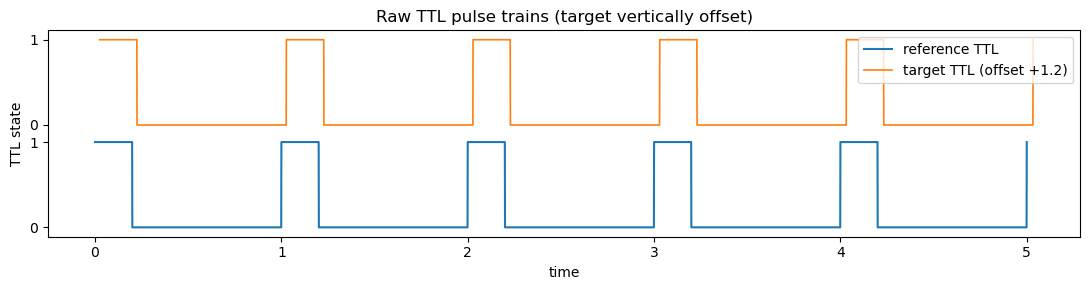

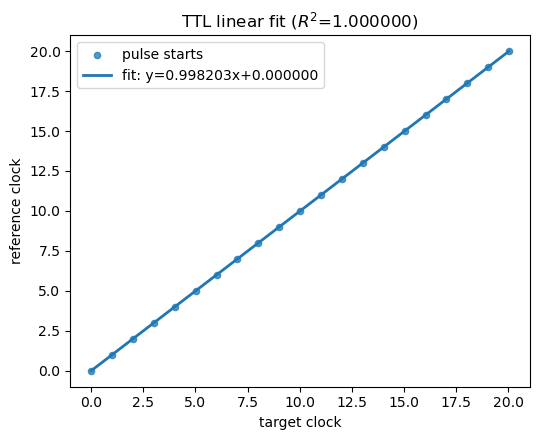

create_global_clock -> ndarray len= 20001
index_map_util keys -> ['index_position_array', 'matched_global_times', 'global_stream_time_delta']
  index_position_array: shape=(20001, 2)
  matched_global_times: shape=(20001, 2)
  global_stream_time_delta: shape=(20001,)
segment_boolean_series -> DataFrame shape= (8, 4)


,Start,End,Duration,State
0,0.0,0.599,0.599,1
1,2.5,3.099,0.599,1
2,5.0,5.599,0.599,1
3,7.5,8.100,0.600,1
4,10.0,10.600,0.600,1


slice_event_windows -> n_windows= 4 keys= [3.0, 7.5, 12.0, 16.5]
window[3.0] shape= (1251, 1)


,signal
-0.500,-0.707107
-0.499,-0.703767
-0.498,-0.700411
-0.497,-0.697040
-0.496,-0.693653


window[7.5] shape= (1251, 1)


,signal
-0.500,1.000000
-0.499,0.999989
-0.498,0.999956
-0.497,0.999900
-0.496,0.999822


In [11]:
# 6b) Explicit function-by-function checks and visuals
import matplotlib.pyplot as plt

# --- Structure previews for each core TTL function output ---
print("extract_ttl_segments -> ref_segments:", ref_segments.shape, "tgt_segments:", tgt_segments.shape)
display(ref_segments.head(5))
display(tgt_segments.head(5))

print("align_pulse_tables -> aligned_ref:", aligned_ref.shape, "aligned_tgt:", aligned_tgt.shape)
display(aligned_ref.head(5))
display(aligned_tgt.head(5))

print("fit_linear_timebase ->", fit_stats)
print("TTLSyncModel ->", {"slope": sync_model.slope, "intercept": sync_model.intercept, "r2": sync_model.r2})

# Demonstrate convert_timebase explicitly and compare against model.transform
t_tgt_to_ref_via_fn = convert_timebase(t_tgt, slope=sync_model.slope, intercept=sync_model.intercept)
max_abs_diff = float(np.max(np.abs(t_tgt_to_ref_via_fn - t_tgt_to_ref)))
print("convert_timebase equivalence max abs diff:", max_abs_diff)

# --- Visualization 1: raw TTL traces (first 5 s) ---
mask_ref = (t_ref >= 0) & (t_ref <= 5)
mask_tgt = (t_tgt >= t_tgt.min()) & (t_tgt <= (5 * 1.0018 + 0.025))

plt.figure(figsize=(11, 3))
plt.plot(t_ref[mask_ref], v_ref[mask_ref], label="reference TTL", lw=1.5)
plt.plot(t_tgt[mask_tgt], v_tgt[mask_tgt] + 1.2, label="target TTL (offset +1.2)", lw=1.2)
plt.yticks([0, 1, 1.2, 2.2], ["0", "1", "0", "1"])
plt.xlabel("time")
plt.ylabel("TTL state")
plt.title("Raw TTL pulse trains (target vertically offset)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# --- Visualization 2: fitted timebase relation (Start edges) ---
if {"Start", "End"}.issubset(aligned_ref.columns) and {"Start", "End"}.issubset(aligned_tgt.columns):
    x = aligned_tgt["Start"].to_numpy(float)
    y = aligned_ref["Start"].to_numpy(float)
    y_hat = sync_model.slope * x + sync_model.intercept

    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(x, y, s=20, alpha=0.75, label="pulse starts")
    plt.plot(x, y_hat, lw=2, label=f"fit: y={sync_model.slope:.6f}x+{sync_model.intercept:.6f}")
    plt.xlabel("target clock")
    plt.ylabel("reference clock")
    plt.title(f"TTL linear fit ($R^2$={sync_model.r2:.6f})")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("Aligned pulse tables do not contain expected Start/End columns.")

# --- Show structures from global-time + segmentation helpers ---
print("create_global_clock ->", type(global_clock).__name__, "len=", len(global_clock))
print("index_map_util keys ->", list(index_map.keys()))
for kk, vv in index_map.items():
    if hasattr(vv, "shape"):
        print(f"  {kk}: shape={vv.shape}")

print("segment_boolean_series ->", type(segments).__name__, "shape=", segments.shape)
display(segments.head(5))

print("slice_event_windows -> n_windows=", len(windows), "keys=", list(windows.keys()))
for w_key in list(windows.keys())[:2]:
    print(f"window[{w_key}] shape=", windows[w_key].shape)
    display(windows[w_key].head(5))

Real pulse counts:
  ref pulses: 282
  tgt pulses: 165


,Start,End,Duration,State
0,29876.160480,29876.922496,0.762016,1
1,29879.204480,29879.740480,0.536000,1
2,29881.925504,29884.676480,2.750976,1
3,29887.621504,29889.694496,2.072992,1
4,29891.362496,29894.063488,2.700992,1


,Start,End,Duration,State
0,11.395067,12.157067,0.762000,1
1,14.439033,14.975033,0.536000,1
2,17.160067,19.911033,2.750967,1
3,22.856067,24.929033,2.072967,1
4,26.597033,29.298033,2.701000,1



Real alignment fit: {'slope': 1.0000018971461295, 'intercept': 8.500387147702857e-05, 'r2': 0.9999999999999637}


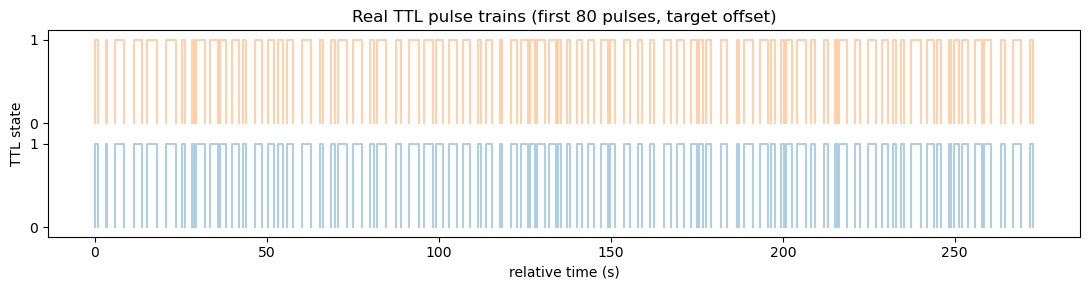

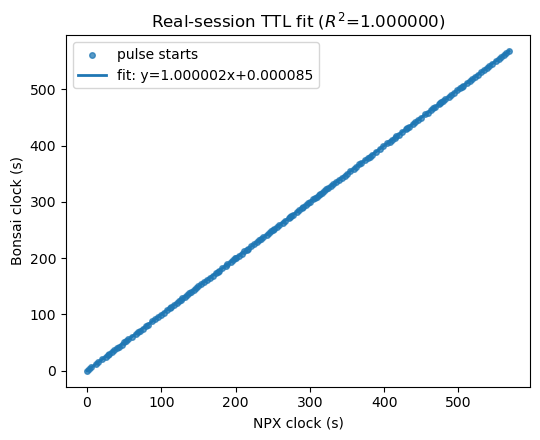

In [12]:
# 6d) Build real pulse tables and align clocks
from data_conduit.datasource.devices import HarpDevice

# --- Load sync board registers from real session ---
sync_loader = HarpDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type="Behavior",
    device_list=[sync_behavior_device],
    device_registers_dict={sync_behavior_device: ["34", "35"]},
    verbose=False,
)

sync_reg34 = sync_loader.dfs_dict[sync_behavior_device]["34"]
sync_reg35 = sync_loader.dfs_dict[sync_behavior_device]["35"]

# Register 34 contains set events, register 35 contains clear events.
# We use DO1 as the TTL sync channel.
ref_starts = sync_reg34.index[sync_reg34["DO1"].astype(bool)].to_numpy(float)
ref_ends = sync_reg35.index[sync_reg35["DO1"].astype(bool)].to_numpy(float)

n_ref = min(len(ref_starts), len(ref_ends))
ref_pulses_real = pd.DataFrame({
    "Start": ref_starts[:n_ref],
    "End": ref_ends[:n_ref],
})
ref_pulses_real["Duration"] = ref_pulses_real["End"] - ref_pulses_real["Start"]
ref_pulses_real["State"] = 1

# --- Extract NPX pulses from sync channel npy ---
npx_sync_raw = np.load(npx_sync_path)
# Data appears binary-like 0/100; threshold > 0 is robust here
npx_binary = (npx_sync_raw > 0).astype(np.int8)
edges = np.diff(npx_binary, prepend=npx_binary[0])
npx_start_idx = np.where(edges == 1)[0]
npx_end_idx = np.where(edges == -1)[0]

# convert sample indices to seconds
npx_sample_rate_hz = 30000.0
npx_starts_sec = npx_start_idx / npx_sample_rate_hz
npx_ends_sec = npx_end_idx / npx_sample_rate_hz

n_tgt = min(len(npx_starts_sec), len(npx_ends_sec))
tgt_pulses_real = pd.DataFrame({
    "Start": npx_starts_sec[:n_tgt],
    "End": npx_ends_sec[:n_tgt],
})
tgt_pulses_real["Duration"] = tgt_pulses_real["End"] - tgt_pulses_real["Start"]
tgt_pulses_real["State"] = 1

print("Real pulse counts:")
print("  ref pulses:", len(ref_pulses_real))
print("  tgt pulses:", len(tgt_pulses_real))
display(ref_pulses_real.head(5))
display(tgt_pulses_real.head(5))

# --- Align + fit with ttlsync ---
ref_aligned_real, tgt_aligned_real = align_pulse_tables(ref_pulses_real, tgt_pulses_real)
fit_real = fit_linear_timebase(ref_aligned_real, tgt_aligned_real, use="start")
model_real = TTLSyncModel(**fit_real)

print("\nReal alignment fit:", fit_real)

# --- Visualize real pulses (relative to first pulse for readability) ---
ref_rel = ref_aligned_real.copy()
tgt_rel = tgt_aligned_real.copy()
ref_rel[["Start", "End"]] = ref_rel[["Start", "End"]] - ref_rel["Start"].iloc[0]
tgt_rel[["Start", "End"]] = tgt_rel[["Start", "End"]] - tgt_rel["Start"].iloc[0]

plt.figure(figsize=(11, 3))
for s, e in ref_rel[["Start", "End"]].to_numpy()[:80]:
    plt.plot([s, s, e, e], [0, 1, 1, 0], color="tab:blue", alpha=0.35)
for s, e in tgt_rel[["Start", "End"]].to_numpy()[:80]:
    plt.plot([s, s, e, e], [1.25, 2.25, 2.25, 1.25], color="tab:orange", alpha=0.35)
plt.yticks([0, 1, 1.25, 2.25], ["0", "1", "0", "1"])
plt.title("Real TTL pulse trains (first 80 pulses, target offset)")
plt.xlabel("relative time (s)")
plt.ylabel("TTL state")
plt.tight_layout()
plt.show()

# --- Visualize fitted mapping ---
x_real = tgt_aligned_real["Start"].to_numpy(float)
y_real = ref_aligned_real["Start"].to_numpy(float)
yhat_real = model_real.slope * x_real + model_real.intercept

plt.figure(figsize=(5.5, 4.5))
plt.scatter(x_real, y_real, s=16, alpha=0.75, label="pulse starts")
plt.plot(x_real, yhat_real, lw=2, label=f"fit: y={model_real.slope:.6f}x+{model_real.intercept:.6f}")
plt.xlabel("NPX clock (s)")
plt.ylabel("Bonsai clock (s)")
plt.title(f"Real-session TTL fit ($R^2$={model_real.r2:.6f})")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

conversion_ratio (target->reference slope): 1.0000018971461295
fit stats: {'slope': 1.0000018971461295, 'intercept': 8.500387147702857e-05, 'r2': 0.9999999999999637}


,Start,End,Duration,State,Start_to_ref,End_to_ref,Duration_to_ref
0,0.000000,0.762000,0.762000,1,0.000085,0.762086,0.762001
1,3.043967,3.579967,0.536000,1,3.044057,3.580058,0.536001
2,5.765000,8.515967,2.750967,1,5.765096,8.516068,2.750972
3,11.461000,13.533967,2.072967,1,11.461107,13.534077,2.072971
4,15.201967,17.902967,2.701000,1,15.202081,17.903086,2.701005
5,20.626933,23.439933,2.813000,1,20.627057,23.440063,2.813005
6,25.247933,26.181933,0.934000,1,25.248066,26.182068,0.934002
7,28.049933,28.889933,0.840000,1,28.050072,28.890073,0.840002


legacy alias ratio matches generic: True


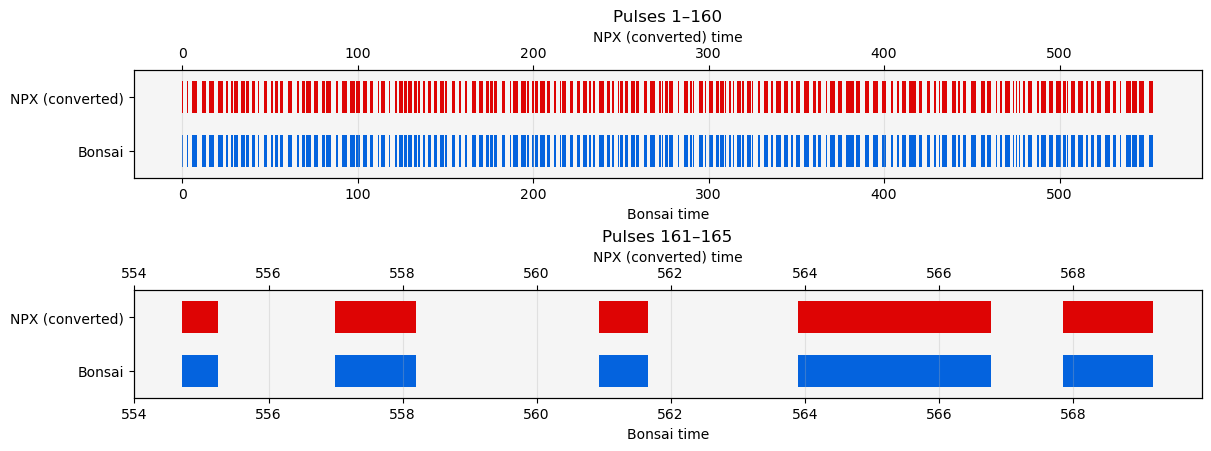

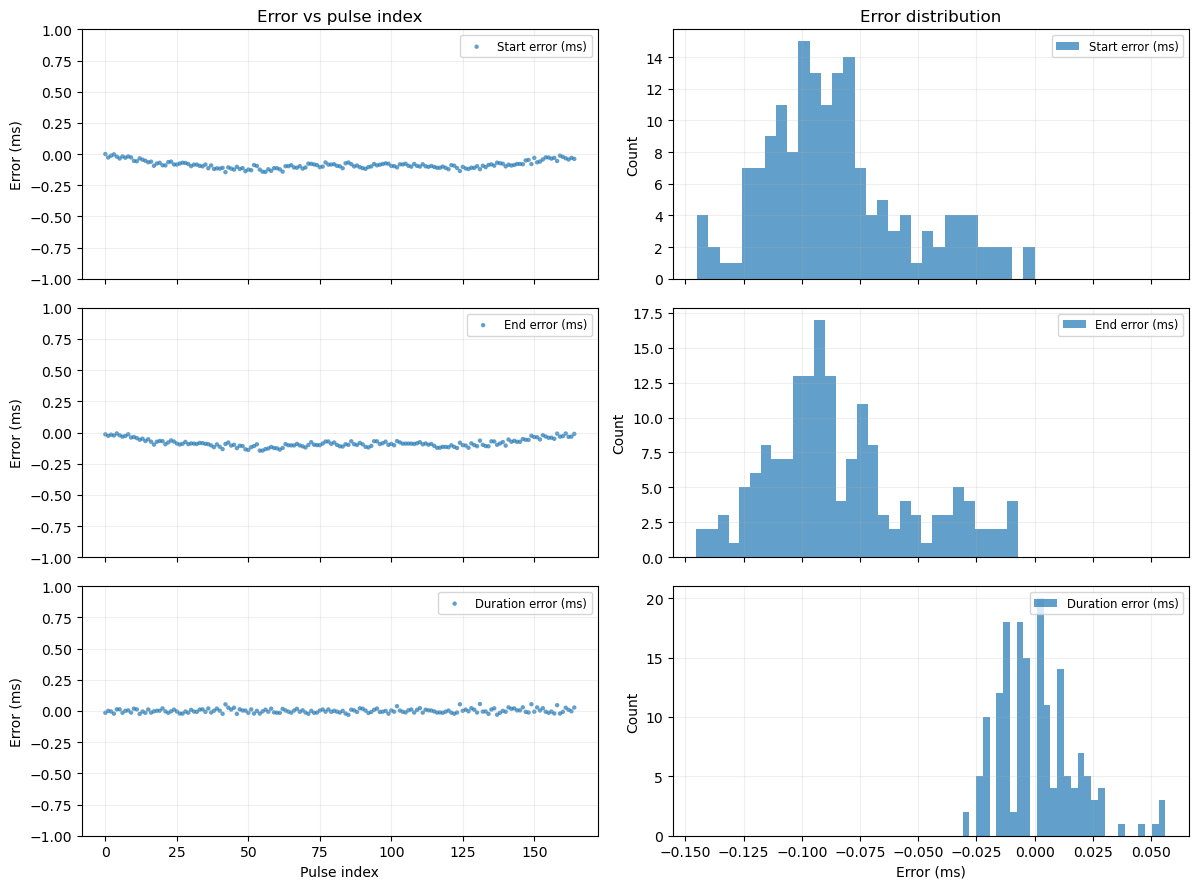

In [13]:
# 6e) Workflow_v2-equivalent visualisation pack (stacked pulses + error tools)
aligned_target_converted, conversion_ratio, ttl_model, ttl_fit = get_ttl_timebase_conversion(
    reference_pulses=ref_pulses_real,
    target_pulses=tgt_pulses_real,
    use="start",
    normalise_start=True,
    visualisation=True,               # stacked pulse rows (v2 style)
    error_visualisation_tools=True,   # per-pulse error scatter + hist
    reference_label="Bonsai",
    target_label="NPX (converted)",
    return_details=True,
 )
print("conversion_ratio (target->reference slope):", conversion_ratio)
print("fit stats:", ttl_fit)
display(aligned_target_converted.head(8))

# Backward-compatible alias still available (same visual controls)
_, legacy_ratio = get_npx_to_bonsai_time_conversion(
    reference_pulses=ref_pulses_real,
    target_pulses=tgt_pulses_real,
    use="start",
    normalise_start=True,
 )
print("legacy alias ratio matches generic:", np.isclose(legacy_ratio, conversion_ratio))

### 6c) Real-session TTL alignment using `Misc/2025-10-14T18-24-42` + `sync_channel_1014.npy`
This demonstrates TTL alignment on real acquired data:
- Bonsai/HARP sync pulses from `Behavior3` registers 34/35 (`DO1`)
- NPX sync pulses from `sync_channel_1014.npy`

It uses the same `ttlsync` helpers as above, but now on session data.

### 6a) TTL visualizations + per-function output inspection
This section makes each synchronization helper explicit by showing:
- pulse-table structures (`extract_ttl_segments`, `align_pulse_tables`)
- fit quality (`fit_linear_timebase`, `TTLSyncModel`)
- conversion equivalence (`convert_timebase` vs `TTLSyncModel.transform`)
- visual checks (pulse traces + linear fit plot)

## 7) Master workflow function pattern (new architecture)
This function follows the same idea as old `Workflow_v2`: collect all outputs into one `results` dictionary.

In [14]:
def run_master_workflow(
    experiment_directory_path,
    harp_device_yaml_path,
    soundcard_yaml_path,
    device_list,
    device_IDs,
    device_registers_dict,
    peripheral_list,
    peripheral_localIDs,
    data_registerIDs,
    verbose=False,
):
    """Run a Workflow_v2-style unified pipeline using new data_conduit modules."""

    # 1) Build virtual maps
    virtual_maps = MultiDevice.build_virtual_maps(
        channel_list=peripheral_list,
        data_registerIDs=data_registerIDs,
        device_list=device_list,
        channel_localIDs=peripheral_localIDs,
    )

    # 2) Multi-device
    multidevice = MultiDevice(
        experiment_directory_path=experiment_directory_path,
        harp_device_yaml_path=harp_device_yaml_path,
        device_type="Behavior",
        device_list=device_list,
        device_IDs=device_IDs,
        device_registers_dict=device_registers_dict,
        virtual_maps=virtual_maps,
        data_keys=list(virtual_maps.keys()),
        global_coord_name="peripherals",
        virtual_coord_names=["device", "register", "localID"],
        verbose=verbose,
    )

    # 3) Optional single-device + filetype wrappers
    try:
        soundcard = SoundCard(
            experiment_directory_path=experiment_directory_path,
            harp_device_yaml_path=soundcard_yaml_path,
            verbose=verbose,
        )
    except Exception:
        soundcard = None

    filetype_objects = {}
    for name, cls in [
        ("experiment_events", ExperimentEvents),
        ("video_data", VideoData),
        ("visual_environment", VisualEnvironment),
    ]:
        try:
            filetype_objects[name] = cls(
                experiment_directory_path=experiment_directory_path,
                verbose=verbose,
            )
        except Exception:
            filetype_objects[name] = None

    # 4) Build unified results dictionary
    results = {}
    for dk, da in multidevice.data_arrays.items():
        results[f"multidevice_{dk}"] = {
            "data": da,
            "lookup": multidevice.lookup_arrays[dk],
        }

    if soundcard is not None:
        for key, da in soundcard.data_arrays.items():
            results[f"soundcard_{key}"] = {"data": da}

    for name, obj in filetype_objects.items():
        if obj is not None:
            results[name] = {"data": obj.dfs_dict}

    return results

In [15]:
# 8) Example call (kept commented for safety)
results = run_master_workflow(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    soundcard_yaml_path=soundcard_yaml_path,
    device_list=device_list,
    device_IDs=device_IDs,
    device_registers_dict=device_registers_dict,
    peripheral_list=peripheral_list,
    peripheral_localIDs=peripheral_localIDs,
    data_registerIDs=data_registerIDs,
    verbose=False,
)
list(results.keys())

['multidevice_Activations',
 'multidevice_LED_Activations',
 'soundcard_PlaySoundFreq',
 'soundcard_StopLog',
 'soundcard_AttenuationRight',
 'experiment_events',
 'video_data',
 'visual_environment']

## 8a) Explore unified `results` like a tutorial table browser
The old workflow included many explicit table outputs. This helper recreates that style by converting each result object into a readable table preview.

## 9) Validation + quick diagnostics
This section adds lightweight checks and visual summaries so you can verify modules are behaving as expected.

It is intentionally **smoke-test style**:
- validates key objects exist
- checks array/table shapes are non-empty
- reports pass/fail in a summary table
- optionally plots quick diagnostics if `matplotlib` is available.

In [16]:
# 8b) Display unified results in tabular previews

def display_results_as_dataframes(results_dict, max_rows=10):
    def _to_df(obj):
        if hasattr(obj, "to_dataframe"):
            try:
                return obj.to_dataframe().reset_index()
            except Exception:
                pass
        if isinstance(obj, pd.DataFrame):
            return obj
        if isinstance(obj, pd.Series):
            return obj.to_frame(name=obj.name if obj.name else "value")
        if isinstance(obj, dict):
            return pd.DataFrame({"key": list(obj.keys()), "value_type": [type(v).__name__ for v in obj.values()]})
        return pd.DataFrame({"value": [str(obj)]})

    print(f"Top-level result entries: {len(results_dict)}")
    for k, v in results_dict.items():
        print(f"\n=== {k} ===")
        if isinstance(v, dict) and "data" in v:
            display(_to_df(v["data"]).head(max_rows))
        elif isinstance(v, dict):
            for sk, sv in v.items():
                print(f"-- {sk}")
                display(_to_df(sv).head(max_rows))
        else:
            display(_to_df(v).head(max_rows))

display_results_as_dataframes(results, max_rows=8)

Top-level result entries: 8

=== multidevice_Activations ===


,Time,peripherals,device,register,localID,Activations_data
0,29872.272992,Nosepoke0,Behavior0,32,DIPort0,NaN
1,29872.272992,Nosepoke1,Behavior0,32,DIPort1,NaN
2,29872.272992,Nosepoke2,Behavior0,32,DIPort2,NaN
3,29872.272992,Nosepoke3,Behavior1,32,DIPort0,NaN
4,29872.272992,Nosepoke4,Behavior1,32,DIPort1,NaN
5,29872.272992,Nosepoke5,Behavior1,32,DIPort2,NaN
6,29872.273984,Nosepoke0,Behavior0,32,DIPort0,NaN
7,29872.273984,Nosepoke1,Behavior0,32,DIPort1,NaN



=== multidevice_LED_Activations ===


,Time,peripherals,device,register,localID,LED_Activations_data
0,29872.272992,Nosepoke0,Behavior0,34,DOPort0,NaN
1,29872.272992,Nosepoke1,Behavior0,34,DOPort1,NaN
2,29872.272992,Nosepoke2,Behavior0,34,DOPort2,NaN
3,29872.272992,Nosepoke3,Behavior1,34,DOPort0,NaN
4,29872.272992,Nosepoke4,Behavior1,34,DOPort1,NaN
5,29872.272992,Nosepoke5,Behavior1,34,DOPort2,NaN
6,29872.273984,Nosepoke0,Behavior0,34,DOPort0,NaN
7,29872.273984,Nosepoke1,Behavior0,34,DOPort1,NaN



=== soundcard_PlaySoundFreq ===


...

,key,value_type
0,ExperimentEvents,dict



=== video_data ===


,key,value_type
0,VideoData,dict



=== visual_environment ===


,key,value_type
0,VisualEnvironment,dict


In [17]:
# 9a) Smoke tests + compact report
checks = []

def record_check(name, fn):
    try:
        ok, detail = fn()
        checks.append({"check": name, "ok": bool(ok), "detail": str(detail)})
    except Exception as e:
        checks.append({"check": name, "ok": False, "detail": f"{type(e).__name__}: {e}"})

record_check("MultiDevice loaded", lambda: ("multidevice" in globals(), "multidevice in globals()"))
record_check("Nosepoke loaded", lambda: ("nosepoke" in globals(), "nosepoke in globals()"))
record_check("SoundCard loaded", lambda: ("soundcard" in globals(), "soundcard in globals()"))
record_check("VideoData loaded", lambda: ("video_data" in globals(), "video_data in globals()"))
record_check("VisualEnvironment loaded", lambda: ("vis_env" in globals(), "vis_env in globals()"))

record_check(
    "MultiDevice has arrays",
    lambda: (len(multidevice.data_arrays) > 0, f"n_data_arrays={len(multidevice.data_arrays)}"),
)
record_check(
    "MultiDevice has lookup arrays",
    lambda: (len(multidevice.lookup_arrays) > 0, f"n_lookup_arrays={len(multidevice.lookup_arrays)}"),
)
record_check(
    "TTL sync slope plausible",
    lambda: (0.95 < float(sync_model.slope) < 1.05, f"slope={float(sync_model.slope):.6f}"),
)
record_check(
    "TTL sync R² high",
    lambda: (float(sync_model.r2) > 0.95, f"r2={float(sync_model.r2):.6f}"),
)
record_check(
    "Event windows non-empty",
    lambda: (all(v.shape[0] > 0 for v in windows.values()), f"window_sizes={[v.shape for v in windows.values()]}"),
)

report = pd.DataFrame(checks)
report["status"] = report["ok"].map({True: "PASS", False: "FAIL"})
display(report[["status", "check", "detail"]])

if not report["ok"].all():
    failed = report.loc[~report["ok"], "check"].tolist()
    print("\nSmoke-test failures:", failed)
else:
    print("\nAll smoke tests passed.")

# 9b) Optional quick visualization (with empty-data guard)
try:
    import matplotlib.pyplot as plt

    first_key = next(iter(multidevice.data_arrays))
    da = multidevice.data_arrays[first_key]
    print(f"Quick view target: {first_key}, shape={da.shape}")

    if da.size == 0:
        print("DataArray is empty (0 samples). Plot skipped.")
    else:
        data = da.values
        finite_count = int(np.isfinite(data).sum())
        if finite_count == 0:
            print("DataArray contains only NaN/inf values. Plot skipped.")
        else:
            plt.figure(figsize=(10, 3))
            n_channels = min(3, da.shape[1] if da.ndim > 1 else 1)
            for i in range(n_channels):
                y = data[:, i] if da.ndim > 1 else data
                plt.plot(y, label=f"ch{i}", alpha=0.8)

            plt.title(f"Quick view: {first_key}")
            plt.xlabel("sample index")
            plt.ylabel("value")
            plt.legend(loc="best")
            plt.tight_layout()
            plt.show()
except Exception as e:
    print(f"Visualization skipped: {type(e).__name__}: {e}")

,status,check,detail
0,PASS,MultiDevice loaded,multidevice in globals()
1,PASS,Nosepoke loaded,nosepoke in globals()
2,PASS,SoundCard loaded,soundcard in globals()
3,PASS,VideoData loaded,video_data in globals()
4,PASS,VisualEnvironment loaded,vis_env in globals()
5,PASS,MultiDevice has arrays,n_data_arrays=2
6,PASS,MultiDevice has lookup arrays,n_lookup_arrays=2
7,PASS,TTL sync slope plausible,slope=0.998203
8,PASS,TTL sync R² high,r2=1.000000
9,PASS,Event windows non-empty,"window_sizes=[(1251, 1), (1251, 1), (1251, 1),..."



All smoke tests passed.
Quick view target: Activations, shape=(1081865, 6)
DataArray contains only NaN/inf values. Plot skipped.


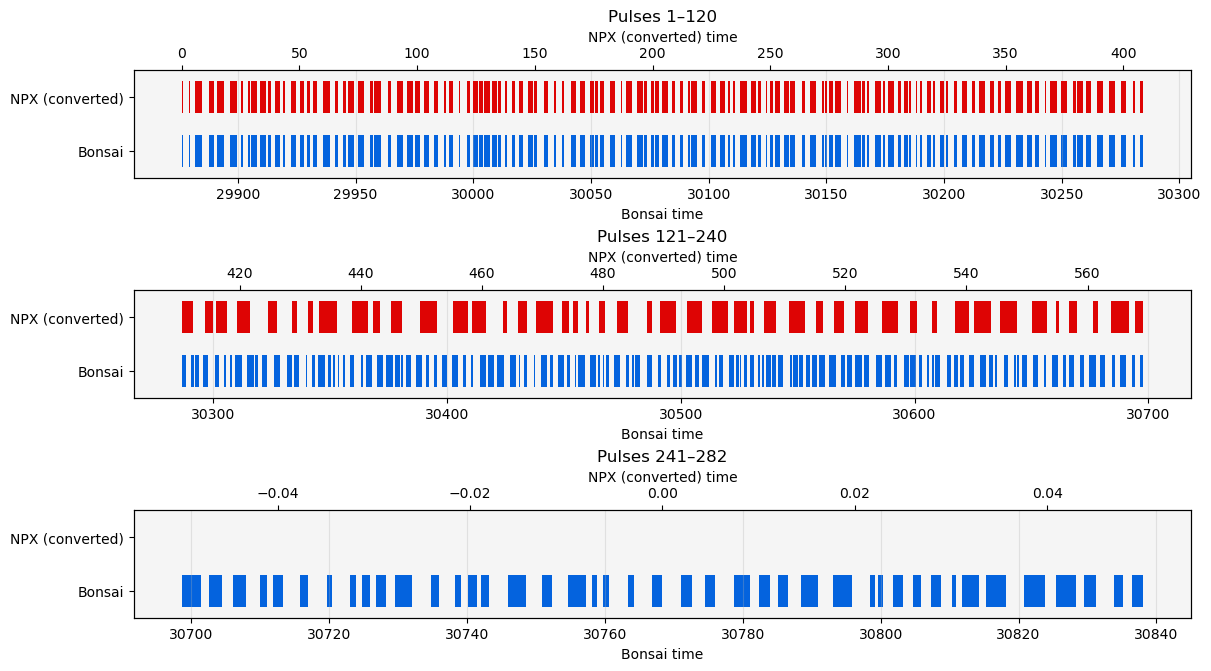

In [18]:
# 9c) Stacked pulse plot (Workflow_v2 style)
import matplotlib.pyplot as plt
from data_conduit.ttlsync import plot_stacked_pulses

if "ref_pulses_real" in globals() and "aligned_target_converted" in globals():
    converted_for_plot = aligned_target_converted.copy()
    converted_for_plot["Start"] = converted_for_plot["Start_to_ref"]
    converted_for_plot["End"] = converted_for_plot["End_to_ref"]
    converted_for_plot["Duration"] = converted_for_plot["Duration_to_ref"]

    plot_stacked_pulses(
        reference_pulses=ref_pulses_real,
        target_pulses=converted_for_plot,
        pulses_per_row=120,
        autofit_pulses_per_row=False,
        reference_label="Bonsai",
        target_label="NPX (converted)",
    )
    plt.show()
else:
    print("Run Cell 21 first to generate aligned_target_converted, then rerun this cell.")

## 10) Parity notes vs old Workflow_v2
Compared with the legacy notebook, this demo now includes:
- richer conceptual explanations
- stepwise output inspection for `MultiDevice` and filetype loaders
- unified results table browser
- smoke-test diagnostics with pass/fail reporting

Still not fully mirrored from the old notebook:
- real NPX/Bonsai pulse-alignment walkthrough on session files
- video timestamp extraction from an actual video file
- extensive plotting gallery for each stream type
- long-form external dependency notes and resource links

The current notebook is now a practical tutorial + validation baseline. Additional old-style deep-dive sections can be appended as optional advanced modules.